In [23]:
# importar librerias con las cuales vamos a trabajar
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st
import seaborn as sns
import requests
from scipy.stats import levene
from bs4 import BeautifulSoup

In [3]:
# recuperamos infomacion sombre la tabla de la siguiente pagina con los datos del clima.
URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html'
req = requests.get(URL)
soup = BeautifulSoup(req.text,'lxml')

headers = []
elements = soup.find('table', attrs = {'id': 'weather_records'})
for row in elements.find_all('th'):
    headers.append(row.text)
    
content = []
elements = soup.find('table', attrs = {'id': 'weather_records'})
for row in elements.find_all('tr'):
    if not row.find_all('th'):
        content.append([element.text for element in row.find_all('td')])

weather_records = pd.DataFrame(content, columns=headers)
print(weather_records)

           Date and time Temperature       Description
0    2017-11-01 00:00:00     276.150     broken clouds
1    2017-11-01 01:00:00     275.700  scattered clouds
2    2017-11-01 02:00:00     275.610   overcast clouds
3    2017-11-01 03:00:00     275.350     broken clouds
4    2017-11-01 04:00:00     275.240     broken clouds
..                   ...         ...               ...
692  2017-11-29 20:00:00     281.340        few clouds
693  2017-11-29 21:00:00     281.690      sky is clear
694  2017-11-29 22:00:00     281.070        few clouds
695  2017-11-29 23:00:00     280.060      sky is clear
696  2017-11-30 00:00:00     278.460      sky is clear

[697 rows x 3 columns]


In [12]:
# Cargar los csv correspondientes
trips_by_company = pd.read_csv('moved_project_sql_result_01.csv')
trips_drop = pd.read_csv('moved_project_sql_result_04.csv')
trips_with_weather =pd.read_csv('moved_project_sql_result_07.csv')

In [13]:
# verificar si los datos estan sucios

print(f' Total de datos duplicados: {trips_by_company.duplicated().sum()}')
print(f' Total de datos nulos: \n{trips_by_company.isnull().sum()}')
trips_by_company.info()
trips_by_company.head()

 Total de datos duplicados: 0
 Total de datos nulos: 
company_name    0
trips_amount    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


#### Como podemos observar los datos del total de viajes por agencia de taxis no presentan ninguna anomalia, no se presentan valores vacios ni duplicados que afecten el analisis y de la misma manera el tipo de datos es correcto para el uso que se les puede dar

In [14]:
# verificar si los datos estan sucios

print(f' Total de datos duplicados: {trips_drop.duplicated().sum()}')
print(f' Total de datos nulos: \n{trips_drop.isnull().sum()}')
trips_drop.info()
trips_drop.head()

 Total de datos duplicados: 0
 Total de datos nulos: 
dropoff_location_name    0
average_trips            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


#### Como podemos observar los datos del promedio de los ultimos destinos de los viajes, no presentan ninguna anomalia con la informacion, no se presentan valores vacios ni duplicados que afecten el analisis y de la misma manera el tipo de datos es correcto para el uso que se les puede dar.

In [15]:
# verificar si los datos estan sucios

print(f' Total de datos duplicados: {trips_with_weather.duplicated().sum()}')
print(f' Total de datos nulos: \n{trips_with_weather.isnull().sum()}')
trips_with_weather.info()
trips_with_weather.head()

 Total de datos duplicados: 197
 Total de datos nulos: 
start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [18]:
# Limpiar datos

trips_with_weather_clean = trips_with_weather.drop_duplicates()
print(f' Total de datos duplicados: {trips_with_weather_clean.duplicated().sum()}')
trips_with_weather_clean.info()
trips_with_weather_clean.sample(5)

 Total de datos duplicados: 0
<class 'pandas.core.frame.DataFrame'>
Index: 871 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            871 non-null    object 
 1   weather_conditions  871 non-null    object 
 2   duration_seconds    871 non-null    float64
dtypes: float64(1), object(2)
memory usage: 27.2+ KB


,start_ts,weather_conditions,duration_seconds
678,2017-11-04 16:00:00,Bad,3058.0
631,2017-11-18 12:00:00,Bad,2877.0
919,2017-11-04 06:00:00,Good,1519.0
133,2017-11-11 12:00:00,Good,2071.0
511,2017-11-04 20:00:00,Good,2220.0


#### Como podemos observar los datos del promedio de los ultimos destinos de los viajes, no presentan ninguna anomalia con la informacion, no se presentan valores vacios que afecten el analisis sin embargo cuenta con aproximadamente 197 datos duplicados, equivalentes al 18.44% de los datos, los cuales se eliminaron para evitar cualquier ruido en los resultados.

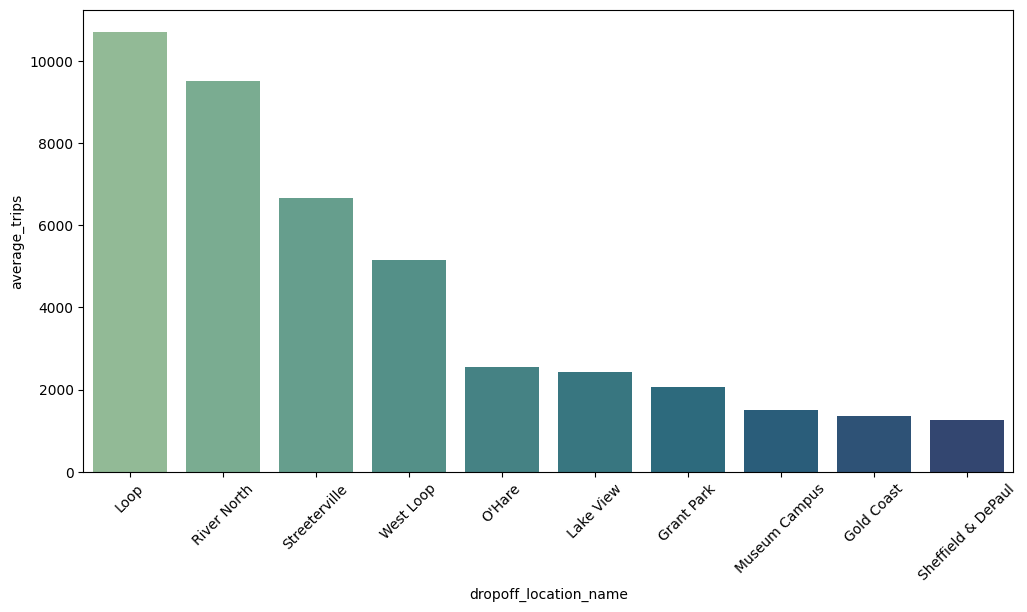

,dropoff_location_name,average_trips
0,Loop,10727.47
1,River North,9523.67
2,Streeterville,6664.67
3,West Loop,5163.67
4,O'Hare,2546.90
5,Lake View,2420.97
6,Grant Park,2068.53
7,Museum Campus,1510.00
8,Gold Coast,1364.23
9,Sheffield & DePaul,1259.77


In [19]:
# Ordenar los datos para su visualizacion
top_dropoff = trips_drop.sort_values(by=['average_trips'], ascending= False)

# Graficar los 10 lugares donde mas terminan recorrido.
plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=top_dropoff.head(10),
                      x='dropoff_location_name',
                      y='average_trips',
                      palette="crest",
                      hue = 'dropoff_location_name')
plt.xticks(rotation=45)

plt.show()
top_dropoff.round(2).head(10)

#### En la grafica podemos observar que la mayoria de reccoridos finaliza en los siguientes lugares:
    el primer puesto se lo lleva Loop con un promedio de 10727 finalizaciones.
    el segundo lugar se lo lleva River North con un promedio de 9523 finalizaciones
    y el tercer lugar se lo lleva Streetterville con 6664 finalizaciones en promedio

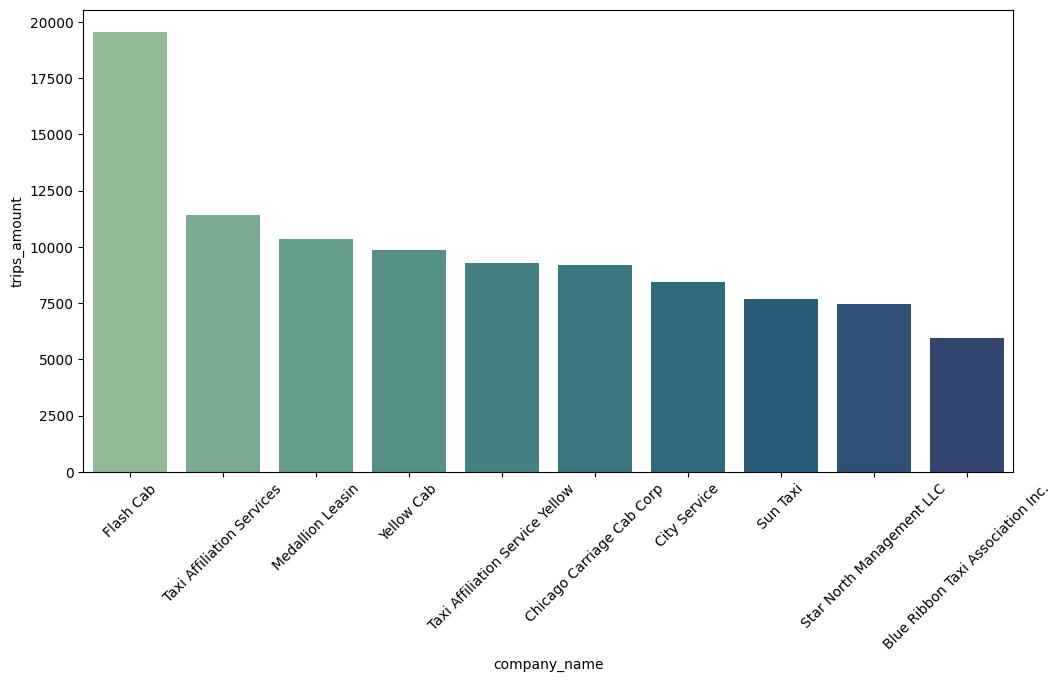

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


In [20]:
# Graficar las 10 empresas de taxis con mayores recorridos
plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=trips_by_company.sort_values (by= ['trips_amount'], ascending= False).head(10),
                      x='company_name',
                      y='trips_amount',
                      palette="crest",
                      hue = 'company_name')
plt.xticks(rotation=45)

plt.show()
trips_by_company.sort_values (by= ['trips_amount'], ascending= False).head(10)

#### En la grafica podemos observar las 10 empresas de taxis con mayores recorridos, en primer lugar vemos a Flash Cab con casi el doble de viajes que la que esta en segundo lugar, podriamos decir que es la favorita por parte de los consumidores.

#### Prueba de hipótesis:

##### — "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare no cambia los sábados lluviosos".

    H0: las duracion promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare no cambia los sábados lluviosos
    H1: las duracion promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos

In [21]:
# alistamos los datos con los cuales vamos a realizar la hipotesis.
rainy_day = trips_with_weather_clean[trips_with_weather_clean['weather_conditions'] == 'Bad']['duration_seconds']
sunny_day = trips_with_weather_clean[trips_with_weather_clean['weather_conditions'] == 'Good']['duration_seconds']

In [24]:
# Prueba Levene para analizar si las varianzas son iguales 
stat, p_value = levene(rainy_day,sunny_day)
print(p_value)
alpha = 0.05
if p_value < alpha:
    print("Las varianzas son desiguales")
else:
    print("Las varianzas son iguales")

0.9806770360671218
Las varianzas son iguales


In [25]:
# nivel crítico de significación estadística
alpha = 0.05

# Varianza de ambas poblaciones

var_rainy_day = np.var(rainy_day)
var_sunny_day = np.var(sunny_day)

# hipotesis sobre igualdad de dos plobaciones, dado que las varianzas son iguales ajustamos el valor a TRUE
results = st.ttest_ind(rainy_day,sunny_day, equal_var = True)


print('valor p:',results.pvalue) 

# Se compara los valores p obtenidos con el nivel de significación estadística
if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

print(f'la duracion promedio de los viajes desde Loop hasta el aeropuerto internacional los dias con mal clima: {rainy_day.mean()}')
print(f'la duracion promedio de los viajes desde Loop hasta el aeropuerto internacional los dias con buen clima: {sunny_day.mean()}')

valor p: 7.397770692813658e-08
Rechazamos la hipótesis nula
la duracion promedio de los viajes desde Loop hasta el aeropuerto internacional los dias con mal clima: 2409.2297297297296
la duracion promedio de los viajes desde Loop hasta el aeropuerto internacional los dias con buen clima: 2032.253112033195


Se plantea la hipotesis para conocer si hay alguna variacion en los tiempos de duracion de los viajes con dias lluviosos o con dias soleados, sin especificarse si aumenta o disminuye el tiempo, podemos identificar en los resultados que al recharzar la hipotesis nula se demuestra que si hay cambios en los tiempos, con un enfoque bilaterla evitamos caer en la trampa de asumir cualquier resultado en solo una direccion, Las hipótesis se plantearon para evaluar si existía cualquier cambio (no especificando dirección) en la duración promedio debido a la lluvia. Los resultados mostraron un aumento significativo, pero el enfoque bilateral garantizó que no se asumiera esto.